# BankAssist Triage — Deployment, App Usage & Governance

This notebook documents how the BankAssist application is run locally, how the live frontend reaches the production API, how the model is loaded in each environment, and how low-confidence predictions are governed.

## Architecture at a glance

```text
LOCAL / DEVELOPMENT
Docker Compose FastAPI (localhost:8000)
        ↓
MODEL_SOURCE=mlflow
        ↓
MLflow BankAssist-Intent-Classifier@champion

LIVE DEMO
Lovable frontend
        ↓ HTTPS POST /predict
Render FastAPI
        ↓
MODEL_SOURCE=local
        ↓
models/champion_model.pkl
```

Lovable does **not** run the classifier. It sends the customer query to FastAPI and displays the returned `intent`, `confidence`, `route`, and `requires_human_review`.


## 1. Data splits

The repository contains separate `train.csv`, `validation.csv`, and `test.csv` splits. The **validation set** is used to discuss and choose the confidence threshold. The **test set is reserved for final evaluation** and must not be used to tune that threshold.


**Repository evidence showing separate train, validation and test CSV files**

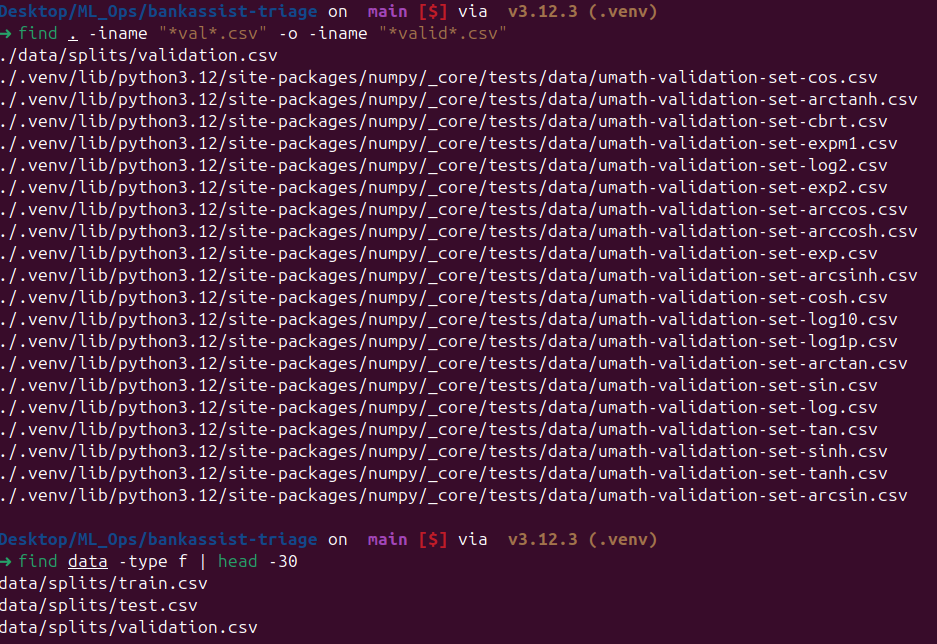


## 2. Run the application locally

From the repository root:

```bash
git pull origin main
cd docker
docker compose up --build -d
docker compose ps
```

Open `http://localhost:8000/docs` for FastAPI and `http://localhost:5001` for MLflow.

Confirm the model source:

```bash
docker compose exec api printenv MODEL_SOURCE
```

The current local Compose configuration returns `mlflow`, so `localhost:8000` loads the model referenced by MLflow's `@champion` alias.

Stop the stack with:

```bash
docker compose down
```


## 3. Test the local API

Swagger lets the API be tested independently of Lovable. A customer message is submitted to `POST /predict`.


**Swagger request submitted to POST /predict**

![Swagger request submitted to POST /predict](attachment:Screenshot from 2026-09-30 16-54-22.png)

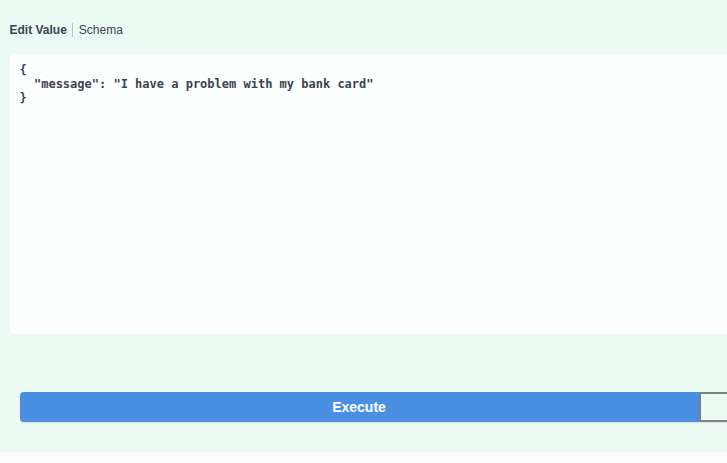

**Successful API response showing intent, confidence, route and human-review decision**

![Successful API response showing intent, confidence, route and human-review decision](attachment:Screenshot from 2026-09-30 16-54-57.png)

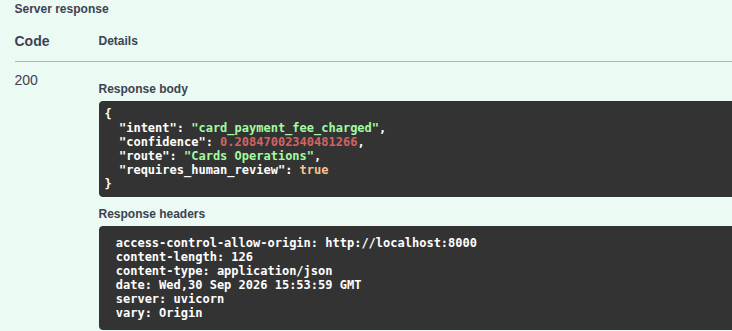

The example returns `card_payment_fee_charged` with confidence ≈ **0.208**, route **Cards Operations**, and `requires_human_review=true`. The classifier supplies the intent/confidence; backend logic supplies the route and review decision.


## 4. MLflow model registry

Local development uses:

```text
models:/BankAssist-Intent-Classifier@champion
```

A host process reaches MLflow at `http://localhost:5001`; the API container uses `http://mlflow:5000`.

The registry below shows that the `champion` alias currently points to **Version 2**.


**MLflow registry showing BankAssist-Intent-Classifier and champion alias on Version 2**

![MLflow registry showing BankAssist-Intent-Classifier and champion alias on Version 2](attachment:Screenshot from 2026-09-30 16-56-11.png)

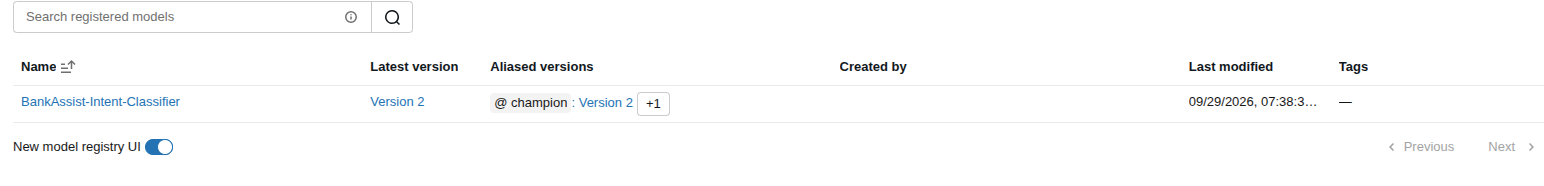

## 5. Production deployment and Lovable connection

The live Lovable frontend sends:

```text
POST https://bankassist-triage.onrender.com/predict
```

The browser Network trace below verifies the live request and HTTP 200 response.


**Firefox Network trace proving Lovable calls the Render prediction API**

![Firefox Network trace proving Lovable calls the Render prediction API](attachment:Screenshot from 2026-09-30 16-58-41.png)

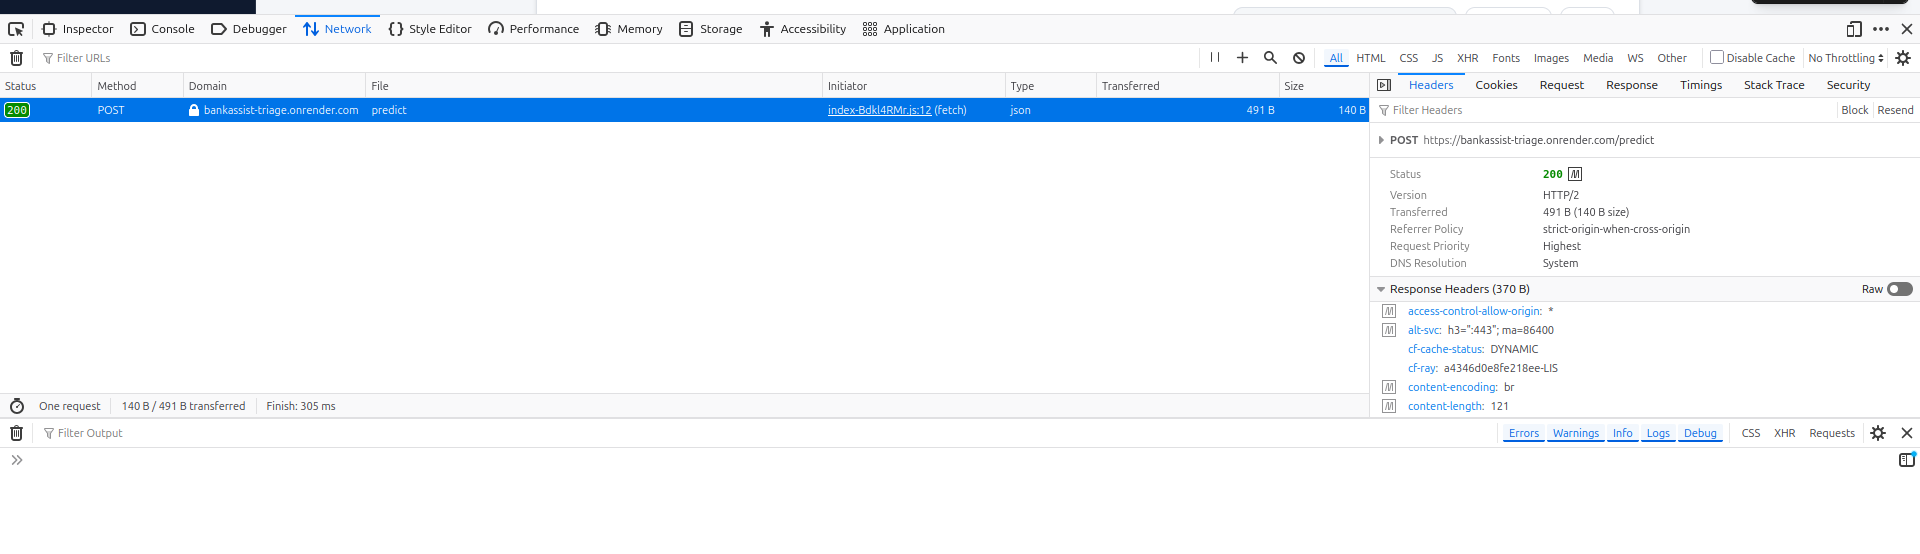

### Production model-loading decision

Render is configured with:

```text
MODEL_SOURCE=local
```

so production loads `models/champion_model.pkl`. This `.pkl` is a deployment snapshot exported from the MLflow champion at export time; Render does **not** continuously query the local MLflow registry. Promoting a new MLflow champion therefore requires exporting the new champion and redeploying production before the live model changes.


# 🛡️ GOVERNANCE — Confidence Threshold & Human Review

## 6. What the threshold does

The confidence threshold is an **operational safeguard**, not another classifier:

```text
confidence < threshold  → requires_human_review = true
confidence ≥ threshold  → eligible for automatic routing
```

It does not alter the predicted intent; it determines whether a prediction is flagged for manual review.

**Current implementation threshold:** verify directly in `api/routing.py` before submission.  
**Team-agreed final threshold (30 September 2026): `__________`**

For this academic prototype, cases marked `requires_human_review=true` represent escalation to an **authorised bank operations/support reviewer**, who would inspect the original query and model suggestion before confirming the destination. A real review queue is not implemented.

The Swagger example above illustrates the safeguard: confidence is only ≈0.208, so the prediction is flagged for human review rather than treated as a reliable automatic routing decision.


## 7. GOVERNANCE — Validation-based threshold decision

Threshold selection must use **validation data only**. The team should compare candidate thresholds (for example 0.40, 0.50, 0.60 and 0.70) using actual validation predictions.

The trade-off is:

- **Higher threshold:** more human-review cases, but fewer uncertain/incorrect predictions are automatically routed.
- **Lower threshold:** lower review workload, but more uncertain predictions are allowed through automatically.

The final analysis should report actual validation results:

| Threshold | Auto-routed | Human review | Review rate | Incorrect auto-routes |
|---:|---:|---:|---:|---:|
| 0.40 | validation result | validation result | validation result | validation result |
| 0.50 | validation result | validation result | validation result | validation result |
| 0.60 | validation result | validation result | validation result | validation result |
| 0.70 | validation result | validation result | validation result | validation result |

Representative validation examples near the decision boundary should also be discussed: ideally at least one incorrect prediction caught by review and one correct prediction that a conservative threshold would nevertheless send to review.

**No numerical validation results are invented here. They must come from `data/splits/validation.csv`.**


### GOVERNANCE LIMITATION

The held-out **test set must not be used to choose or adjust the confidence threshold**. It remains reserved for final unbiased evaluation.

The selected threshold is a **prototype governance choice informed by validation behaviour**. It must not be presented as a calibrated probability threshold or as validated for real banking operations. A real deployment would require probability calibration, operational risk assessment, monitoring, review-capacity planning and validation on representative production data.


## 8. Essential troubleshooting

```bash
# API logs
cd docker
docker compose logs -f api

# Rebuild
docker compose down
docker compose up --build -d

# Port conflict
sudo lsof -nP -iTCP:8000 -sTCP:LISTEN
```

The packaged sklearn model must be loaded with a compatible scikit-learn version, which is pinned in `requirements.txt`.


## 9. Final checklist

- [ ] Local Docker starts and `/health` reports the model loaded.
- [ ] Local `MODEL_SOURCE=mlflow` is confirmed.
- [ ] MLflow `@champion` and its version are documented.
- [ ] Local `/predict` returns all four API response fields.
- [ ] Render `/health` and `/predict` work publicly.
- [ ] Production `MODEL_SOURCE=local` is confirmed.
- [ ] Lovable calls `https://bankassist-triage.onrender.com/predict`.
- [ ] Packaged `.pkl` is described as an exported champion snapshot.
- [ ] Team-agreed threshold is recorded in this notebook/backend.
- [ ] Threshold decision is supported with **validation** examples/results.
- [ ] Test data is **not** used for threshold selection.
- [ ] Threshold is **not** presented as calibrated for real banking operations.
